In [16]:
import pandas as pd
import os

os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

design = pd.read_table('config/samples.hela_tm_tg.tsv', index_col=0)
raw_sj_counts = pd.read_table('results/hela_tm_tg/junctions/SJ_nc_2pass_nc.count.tsv', index_col=[0,1,2,3,4])

#wt_samples = design[design['condition_1'] == 'WT'].index.tolist()
# ko_samples = design[design['condition_1'] == 'KO'].index.tolist()
wt_samples = ['WT_Tg_1', 'WT_Tg_2']
ko_samples = ['KO_Tg_1', 'KO_Tg_2']

raw_sj_counts['WT_total'] = raw_sj_counts[wt_samples].sum(axis=1)
raw_sj_counts['KO_total'] = raw_sj_counts[ko_samples].sum(axis=1)

# filter WT >= 10 & KO <= 1
sj_filtered = raw_sj_counts[
    (raw_sj_counts['WT_total'] >= 10) & (raw_sj_counts['KO_total'] <= 1)
    | ((raw_sj_counts['WT_total'] > 6 * raw_sj_counts['KO_total']) & (raw_sj_counts['KO_total'] > 0))
].copy()

print(f'Original junctions: {raw_sj_counts.shape[0]}')
print(f'Filtered junctions: {sj_filtered.shape[0]}')

Original junctions: 286288
Filtered junctions: 768


In [17]:
import re

# bedops styled bed, 6 columns bed6 + 4 bedops extra columns
transcripts_attr = pd.read_table(
    'references/human_ref/gencode.v49.transcripts.bed',
    header=None,
    names=['chr', 'start', 'end', 'id', 'score', 'strand', 'source', 'feature', 'frame', 'attr'],
)
transcripts_attr.set_index('id', drop=False, inplace=True)

def get_transcript_by_site(row):
    chrom, start, end, *_ = row.name
    overlapping_transcripts_df = transcripts_attr[
        (transcripts_attr['chr'] == chrom) &
        (transcripts_attr['start'] <= start) &
        (transcripts_attr['end'] >= end)
    ]
    if not overlapping_transcripts_df.empty:
        return overlapping_transcripts_df.index.tolist()
    else:
        return None

def get_coding_gene_by_transcript(row):
    transcript = transcripts_attr.loc[row['transcript']]
    # only return protein coding genes
    if 'protein_coding' not in transcript['attr']:
        return None
    symbol = re.sub(r'.*gene_name "(\S*)";.*', r'\1', transcript['attr'])
    return symbol

sj_filtered['transcript'] = sj_filtered.apply(get_transcript_by_site, axis=1)
sj_filtered.dropna(subset=['transcript'], inplace=True) # remove junctions not overlapping with any transcripts
sj_filtered['sj_id'] = sj_filtered.index.map(lambda x: f'{x[0]}:{x[1]}-{x[2]}({x[3]}|{x[4]})')
sj_filtered['size'] = sj_filtered.index.map(lambda x: x[2] - x[1] + 1)
sj_filtered = sj_filtered.explode('transcript')


sj_filtered['genes'] = sj_filtered.apply(get_coding_gene_by_transcript, axis=1)
sj_filtered.dropna(subset=['genes'], inplace=True) # remove transcripts belongs to non coding genes
sj_filtered.reset_index(drop=True, inplace=True)

print(f'Filtered junctions after keeping protein coding genes: {sj_filtered.shape[0]}')
sj_filtered.head(5)


Filtered junctions after keeping protein coding genes: 10734


,KO_DMSO_1,KO_DMSO_2,KO_Tg_1,KO_Tg_2,KO_Tm_1,KO_Tm_2,WT_DMSO_1,WT_DMSO_2,WT_Tg_1,WT_Tg_2,WT_Tm_1,WT_Tm_2,WT_total,KO_total,transcript,sj_id,size,genes
0,1,3,0,1,0,2,2,0,1,6,0,1,7,1,ENST00000379370.7,chr1:1046493-1046620(0|1),128,AGRN
1,1,3,0,1,0,2,2,0,1,6,0,1,7,1,ENST00000620552.4,chr1:1046493-1046620(0|1),128,AGRN
2,1,3,0,1,0,2,2,0,1,6,0,1,7,1,ENST00000651234.1,chr1:1046493-1046620(0|1),128,AGRN
3,1,3,0,1,0,2,2,0,1,6,0,1,7,1,ENST00000652369.2,chr1:1046493-1046620(0|1),128,AGRN
4,1,3,1,0,3,1,1,1,4,3,0,1,7,1,ENST00000900949.1,chr1:1217304-1217314(0|1),11,SDF4


In [18]:
count_by_genes = sj_filtered.copy()
count_by_genes['WT'] = count_by_genes[wt_samples].astype(str).agg(','.join, axis=1)
count_by_genes['KO'] = count_by_genes[ko_samples].astype(str).agg(','.join, axis=1)
count_by_genes.drop_duplicates(subset=['genes', 'sj_id'], inplace=True)
count_by_genes = count_by_genes.groupby([
    'sj_id', 'KO', 'WT', 'size', 'WT_total', 'KO_total'
]).agg(
    { 'genes': lambda x: '/'.join(x.tolist()) }
).reset_index()
count_by_genes.sort_values(by='WT_total', inplace=True, ascending=False)

count_by_genes

,sj_id,KO,WT,size,WT_total,KO_total,genes
362,chr22:28796128-28796153(0|1),"0,0","579,601",26,1180,0,XBP1
496,chr6:34245768-34245789(0|1),"3,2","10,22",22,32,5,HMGA1
269,chr19:6372967-6372980(0|1),"4,1","12,19",14,31,5,ALKBH7
342,chr20:47654853-47654864(0|1),"1,0","11,17",12,28,1,NCOA3
95,chr12:52248600-52248713(0|1),"4,0","11,16",114,27,4,KRT7
...,...,...,...,...,...,...,...
539,chr9:121340281-121340303(0|1),"1,0","5,2",23,7,1,STOM
566,chrX:154348951-154353442(0|1),"1,0","4,3",4492,7,1,FLNA
31,chr11:123194994-123195010(0|1),"1,0","4,3",17,7,1,CLMP
4,chr10:128107112-128108204(0|1),"0,1","3,4",1093,7,1,MKI67


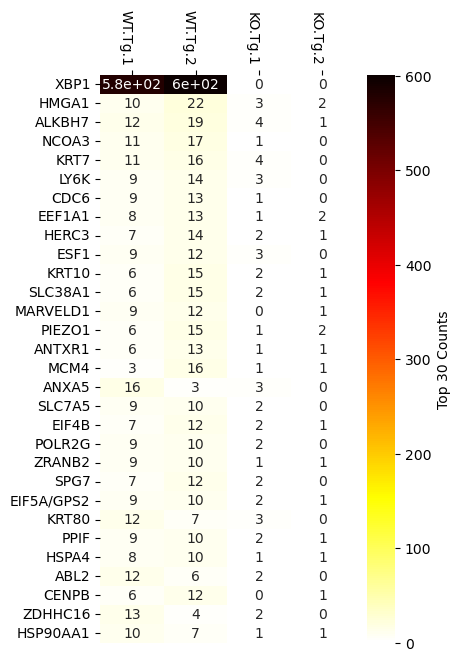

In [20]:
from matplotlib import pyplot as plt
import seaborn as sns

samples = ['WT.Tg.1', 'WT.Tg.2', 'KO.Tg.1', 'KO.Tg.2']
genes = []
data = []
for i, row in count_by_genes.head(30).iterrows():
    genes.append(row['genes'])
    wt_counts = [int(i) for i in row['WT'].split(',')]
    ko_counts = [int(i) for i in row['KO'].split(',')]
    data.append(wt_counts + ko_counts)

fig, ax = plt.subplots(layout='constrained', figsize=(4.5, 6.5), dpi=100)
sns.heatmap(data, ax=ax, cmap='hot_r', cbar_kws={'label': 'Top 30 Counts'},
            yticklabels=genes, xticklabels=samples, annot=True)

ax.set_xticklabels(ax.get_xticklabels(), rotation=-90, ha='right')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

plt.show()
